# BERTje Sentence Analysis

## 1. Preparations

### 1.1 Read Data

In [1]:
import pandas as pd
# read the sentence data
sentence_df = pd.read_excel("/workspace/mijnidbcoachnlp/data/analysis_datasets/input_data/translated_sentence_data.xlsx")
# check the head
sentence_df.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence
0,3,Ik ben 2 weken geleden met spoed opgenomen in ...,Ik ben 2 weken geleden met spoed opgenomen in ...,0,I was rushed into the [PRESSION-1] [LOCATION-1...
1,3,"Ik kreeg acuut een pijnlijke druk op de borst,...","Ik kreeg acuut een pijnlijke druk op de borst,...",1,I was acutely under a painful pressure on the ...
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,2,It started 1 hour after dinner.
3,3,"Ik had al de hele dag migraine, had dus ook we...","Ik had al de hele dag migraine, had dus ook we...",3,"I had migraines all day, so I hadn't eaten much."
4,3,"Ik werd heel erg misselijk, braakneigingen, du...","Ik werd heel erg misselijk, braakneigingen, du...",4,"I got very nauseous, vomiting, dizzy and rejuv..."


In [2]:
# clean sentences as inputs
sentences = sentence_df["Clean_Sentence"].to_list()

### 1.2. Import the annotated dataset

In [3]:
# This is a small sample of 328 sentences
annotated_df_sm = pd.read_excel("/workspace/mijnidbcoachnlp/data/analysis_datasets/labeled_data/sample_sentences_for_labeling_100_coded.xlsx", index_col=0)
# This is a larger sample of 4000 sentences
annotated_df_lg = pd.read_excel("/workspace/mijnidbcoachnlp/data/analysis_datasets/labeled_data/Labeling_sentences_Tom_Sinsel.xlsx", index_col=0)

In [4]:
# check the head
annotated_df_sm = annotated_df_sm.loc[:, ~annotated_df_sm.columns.str.contains('^Unnamed')]
annotated_df_sm.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label_Jiaxu
269,173,"Beste [PERSOON-1], het gaat weer iets beter ...",het gaat weer iets beter en ik heb gisteren de...,269,"Dear [PERSOON-1], things are getting better an...",A4
270,173,Het liep goed totdat ik probeerde de onderkant...,Het liep goed totdat ik probeerde de onderkant...,270,It went well until I tried to break the bottom...,A4
271,173,Ik kreeg het niet voor elkaar en heb toen meer...,Ik kreeg het niet voor elkaar en heb toen meer...,271,I couldn't do it and then I used more power.,A5
272,173,Hij lijkt me nu op de verkeerde plek gebroken ...,j lijkt me nu op de verkeerde plek gebroken (z...,272,It looks like it's broken in the wrong place (...,A5
273,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A4


In [5]:
# check the head of lg set
annotated_df_lg = annotated_df_lg.loc[:, ~annotated_df_lg.columns.str.contains('^Unnamed')]
annotated_df_lg = annotated_df_lg[annotated_df_lg['Manual_label_Tom'].notna()]
annotated_df_lg.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Manual_label_Tom
0,3,Ik ben 2 weken geleden met spoed opgenomen in ...,Ik ben 2 weken geleden met spoed opgenomen in ...,0,M8
1,3,"Ik kreeg acuut een pijnlijke druk op de borst,...","Ik kreeg acuut een pijnlijke druk op de borst,...",1,M8
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,2,A5
3,3,"Ik had al de hele dag migraine, had dus ook we...","Ik had al de hele dag migraine, had dus ook we...",3,M8
4,3,"Ik werd heel erg misselijk, braakneigingen, du...","Ik werd heel erg misselijk, braakneigingen, du...",4,M8


### 1.3. Import the list of stopwords

In [6]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/mijnidbcoachnlp/data/analysis_datasets/stopwords/stopwords.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

extra_list = [
    'maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag',
    'januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli', 'augustus', 'september', 'oktober', 'november', 'december',
    'jan', 'feb', 'mrt', 'apr', 'mei', 'jun', 'jul', 'aug', 'sep', 'okt', 'nov', 'dec', "jl", "weken", "week", "dagen", "dag", "mg"
]

dutch_stopwords.extend(extra_list)

### 1.4. Embed the lists of sentences with sentence-transformer multilingual-v1

In [7]:
from transformers.pipelines import pipeline
from transformers import AutoTokenizer, AutoModel, TFAutoModel
embedding_model = pipeline("feature-extraction", model="GroNLP/bert-base-dutch-cased")

Some weights of BertModel were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
import numpy as np
# load saved bertje sentence-embeddings # we have two different embeddings due to different calculations 
embeddings = np.load("../../data/saved_embeddings/sentence_embeddings_bertje_nl.npy")
#or
#embeddings = np.load("../../data/saved_embeddings/sentence_embeddings_bertje_nl_new.npy") 

In [ ]:
# pre-calculate the sentence embeddings with BERTje if there isn't anything saved 
# calculation 1
import numpy as np

embeddings_nl = embedding_model(sentences, truncation=True, padding=True)
sentence_embeddings_nl = np.array([np.mean(embedding, axis=1).flatten() for embedding in embeddings_nl])
# save the sentence embeddings
import numpy as np
np.save('/workspace/mijnidbcoachnlp/data/saved_embeddings/sentence_embeddings_bertje_nl.npy', sentence_embeddings_nl)

In [ ]:
# calculation two

from tqdm import tqdm 
# Initialize an empty list to store embeddings
sentence_embeddings_nl = []

# Use tqdm to track progress
for sentence in tqdm(sentences, desc="Processing Embeddings", unit="sentence"):
    # Compute embedding for the sentence
    embedding = embedding_model(sentence)
    # Average token embeddings to create a sentence-level embedding
    sentence_embedding = np.mean(embedding[0], axis=0)
    # Append to the list
    sentence_embeddings_nl.append(sentence_embedding)

# Convert the list to a NumPy array
sentence_embeddings_nl = np.array(sentence_embeddings_nl)

# Check the shape of the resulting embeddings
print(f"Shape of sentence embeddings: {sentence_embeddings_nl.shape}")

# save the sentence embeddings
import numpy as np
np.save('/workspace/mijnidbcoachnlp/data/saved_embeddings/sentence_embeddings_bertje_nl_new.npy', sentence_embeddings_nl)

### 1.5 Pre-configure submodels of BERTopic

In [9]:
# set the vectorizer model
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from hdbscan import HDBSCAN
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from umap import UMAP

# configure the sub-models
#vectorizer
vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{3,}\b')
# clustering
hdb_model = HDBSCAN(min_cluster_size=20, min_samples=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# dimension reduction
umap_model=UMAP(n_neighbors=10, n_components=2, metric='cosine', random_state=42)


In [62]:
# function to build the model with different selection of clustering method
# build the BERTopic model
from bertopic import BERTopic

def build_bertopic(embedding_model, umap_model, hdb_model, vectorizer_model, sentences, embeddings):
    
    # Initialize BERTopic with UMAP and HDBSCAN models
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdb_model,
        vectorizer_model=vectorizer_model,
        top_n_words=10,
        verbose=True
    )

    # Fit-transform to get document topics and probabilities
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    

    # Return only essential results
    return topic_model

## 2. Build/Load Model with Outlier Reduction

### 2.1 Load saved model
If you have a saved model, load it. Otherwise go to 2.2.

In [10]:
from bertopic import BERTopic
# load the model (without reduced outliers)
loaded_topic_model = BERTopic.load("/workspace/mijnidbcoachnlp/data/result_data/saved_models/saved_BERTje_model", embedding_model=embedding_model)

In [11]:
# examine the topic info of the loaded model 
loaded_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18991,-1_afspraak_goed_medicatie_ontlasting,"[afspraak, goed, medicatie, ontlasting, vraag,...",NaN
1,0,1820,0_toilet_buikpijn_pijn_buik,"[toilet, buikpijn, pijn, buik, gevoel, last, k...",NaN
2,1,694,1_sturen_wilt_recept apotheek_recept sturen,"[sturen, wilt, recept apotheek, recept sturen,...",NaN
3,2,478,2_nieuw recept_nieuw_recept_graag nieuw,"[nieuw recept, nieuw, recept, graag nieuw, her...",NaN
4,3,443,3_ziekenhuis_apotheek ziekenhuis_ziekenhuis ap...,"[ziekenhuis, apotheek ziekenhuis, ziekenhuis a...",NaN
...,...,...,...,...,...
335,334,20,334_geven buikpijn_nachts wakker_extreem_fit moe,"[geven buikpijn, nachts wakker, extreem, fit m...",NaN
336,335,20,335_aantal last_voet_lage rug_stijfheid pijn,"[aantal last, voet, lage rug, stijfheid pijn, ...",NaN
337,336,20,336_reactie alvast_alvast bedankt_bedankt reac...,"[reactie alvast, alvast bedankt, bedankt react...",NaN
338,337,20,337_test gedaan_calprotectine test_calprotecti...,"[test gedaan, calprotectine test, calprotectin...",NaN


### 2.2 Build and save the BERTopic Model

In [63]:
# disable parallelism to avoid some warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [64]:
# build the model with the preconfigured settings in 1.5
topic_model = build_bertopic(embedding_model, umap_model, hdb_model, vectorizer_model, sentences, embeddings)

2025-01-20 20:40:26,039 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-01-20 20:42:13,809 - BERTopic - Dimensionality - Completed ✓
2025-01-20 20:42:13,814 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-01-20 20:42:19,576 - BERTopic - Cluster - Completed ✓
2025-01-20 20:42:19,606 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-01-20 20:42:21,857 - BERTopic - Representation - Completed ✓


In [65]:
# examine topic information
pd.set_option("max_colwidth", 300) # adjust column width 
topic_model.get_topic_info()[:20]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,19778,-1_last_goed_klachten_medicatie,"[last, goed, klachten, medicatie, gaan, afspraak, krijg, pijn, weet, keer]","[Is het handig om dit te bespreken tijdens een consult of zeggen jullie van start maar komende week?, Kan dit van het medicatie (Stellaris) komen?, Ik voel me echt niet goed ik heb weinig eetlust kan bijna niks eten of ik moet na toilet die diarree is al tijdje aan de gang van begin half juni en..."
1,0,585,0_uur_afspraak_afspraak staan_uur afspraak,"[uur, afspraak, afspraak staan, uur afspraak, gepland, afspraak gepland, afspraak uur, staan, afspraak afspraak, staat afspraak]","[Ik heb op 7 november a.s. een poli-afspraak staan met en op 28 november met en met ., op 10 januari om 09:30 uur, heb ik een afspraak staan bij ., j kan die dag pas vanaf 13 uur.]"
2,1,531,1_ziekenhuis_apotheek ziekenhuis_zorginstelling_ziekenhuis apotheek,"[ziekenhuis, apotheek ziekenhuis, zorginstelling, ziekenhuis apotheek, apotheek, prikken ziekenhuis, ziekenhuis sturen, ziekenhuis recept, ziekenhuis bloed, gestuurd]","[Beide bij het [ZIEKENHUIS] in , ., Nee in het [ZIEKENHUIS] ongeveer 10 december,, 8 januari moet ik weer naar het [ZIEKENHUIS].]"
3,2,455,2_slijm_slijm ontlasting_bloed slijm_bloed ontlasting,"[slijm, slijm ontlasting, bloed slijm, bloed ontlasting, ontlasting, ontlasting ontlasting, bloed, ontlasting bloed, zit bloed, soms]","[Sinds 14 dagen heb ik bloed en slijm bij mijn ontlasting., Ik heb ook weer bloed en slijm bij de ontlasting en meer luchtophopingen., Ik heb geen bloed of slijm bij de ontlasting.]"
4,3,400,3_snelle_bedankt_snelle reactie_bedankt snelle,"[snelle, bedankt, snelle reactie, bedankt snelle, reactie, dank, bedankt reactie, dank snelle, reactie bedankt, reactie dank]","[Ok , bedankt voor je snelle reactie., bedankt voor de snelle reactie, Bedankt voor de snelle reactie!]"
5,4,379,4_verstandig_inleveren_ontlasting inleveren_blijven,"[verstandig, inleveren, ontlasting inleveren, blijven, prikken ontlasting, ontlasting leveren, bloed prikken, doorgaan, cortiment, prikken]","[Maar misschien is het verstandig om dan ook bloed te laten prikken en ontlasting in te leveren?, Moet ik nu weer laten prikken en of ontlasting inleveren?, Moet ik dan nu deze week bloed prikken en ontlasting inleveren?]"
6,5,335,5_infusie_vraag_overleg_omgaand reactie,"[infusie, vraag, overleg, omgaand reactie, schrijven, zaken, ter, ontvangen bevolkingsonderzoek, adviseerde contact, overleg graag]","[Ter info voor het overleg v.w.b., Ik heb vandaag terugkoppeling ontvangen van bevolkingsonderzoek en wordt opgeroepen voor een intake n.a.v., Ik heb vandaag terugkoppeling ontvangen van bevolkingsonderzoek en wordt opgeroepen voor een intake n.a.v.]"
7,6,329,6_ontlasting ingeleverd_ingeleverd_ingeleverd bloed_prikken ontlasting,"[ontlasting ingeleverd, ingeleverd, ingeleverd bloed, prikken ontlasting, geprikt ontlasting, bloed geprikt, bloed laten, ingeleverd ontlasting, geprikt, laten prikken]","[13 mei heb ik bloed laten prikken en mijn ontlasting ingeleverd., Afgelopen vrijdag heb ik bloed laten prikken en ontlasting ingeleverd., Ik heb laatst bloed laten prikken en ontlasting ingeleverd.]"
8,7,301,7_buikpijn_last_buikkrampen_buik,"[buikpijn, last, buikkrampen, buik, misselijk, pijn, nacht, krampen, moe, eetlust]","[Ik blijf last houden van misselijkheid gedurende de hele dag, met soms vreselijke weerzin in eten en drinken., Als ik naar de WC moet heb ik ook buikpijn., Ik voel me de hele dag door beroerd, futloos, de hele dag door heb ik buikpijn, een opgeblazen gevoel en een zichtbaar lichtelijk opgeblaz..."
9,8,293,8_nakijken_helpen_geven_doorgeven,"[nakijken, helpen, geven, doorgeven, wilt, bellen, hiermee helpen, toesturen, laten weten, informatie geven]","[Misschien kunt U dat eens nakijken., Kunnen jullie dat nakijken?, Kunt u dat voor me nakijken aub?]"


In [66]:
# save the model before reducing topics
topic_model.save("/workspace/mijnidbcoachnlp/data/result_data/saved_BERTje_model_test", serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

In [67]:
# save the topic and document information before reducing topics
#save the topic info
topic_info = topic_model.get_topic_info()
topic_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/topic_info_BERTje_test.xlsx', index=False)
#save the topic info
doc_info = topic_model.get_document_info(sentences)
doc_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/doc_info_BERTje_test.xlsx', index=False)

### 2.3. Reduce topics and save the model with reduced topics

In [22]:
topic_model = loaded_topic_model

In [21]:
# Reduce outliers
topics = topic_model.topics_
new_topics = topic_model.reduce_outliers(sentences, topics, strategy="embeddings")

KeyboardInterrupt: 

In [73]:
# update the topics
topic_model.update_topics(sentences, topics=new_topics)

2025-01-20 21:38:27,844 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


ValueError: All arrays must be of the same length

In [ ]:
# examine the topics after outlier reduction
topic_model.get_topic_info()

In [ ]:
# save the model after reducing topics
topic_model.save("/workspace/mijnidbcoachnlp/data/result_data/saved_models/saved_BERTje_model_ro_test", serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

In [ ]:
#save the topic info after topic reduction
topic_info = topic_model.get_topic_info()
topic_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/topic_and_doc_info/bertje/topic_info_bertje_reduced.xlsx', index=False)

doc_info = topic_model.get_document_info(sentences)
doc_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/topic_and_doc_info/bertje/doc_info_bertje_reduced.xlsx', index=False)

## 3. Visualize the results

In [14]:
topic_model = loaded_topic_model # select the topic model you want to visualize

In [12]:
# settings for plotly
import plotly.io as pio
pio.renderers.default = "notebook"
pio.renderers.default = "browser" # option to open the plots in brower

### 3.1 Visualize the hierarchy

In [27]:
hierarchical_topics = topic_model.hierarchical_topics(sentences)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 20/20 [00:00<00:00, 130.47it/s]


### 3.2 Visualize inter-topic distance map

In [17]:
# Visualize the inter-topic distance map
topic_model.visualize_topics()

## 4. Merge topics

In [24]:
# merge some topics
topics_to_merge = [[20, 328, 207, 301], # Diet
                    [281, 158, 278, 263, 259, 41, 13, 220], # Consultation/Hospital Visit
                    [181, 276, 243, 175, 163, 112,311, 246, 325, 216, 312, 321, 303, 306, 175, 163, 112, 188, 40, 129, 142, 204, 148], # Health Update
                    [261, 297, 190, 53, 70, 131, 171, 251, 323, 203, 225, 300, 160, 67, 111, 252, 213, 176, 258, 257, 66, 224, 162, 52, 49,
                    38, 153, 226, 152, 168, 309, 180, 104, 196, 201], # Medical Advice/Discussion
                    [192, 324, 54, 110], # Exam
                    [210, 103, 135, 106, 63, 62, 288, 113, 149, 81, 109, 92, 159, 14, 88, 332, 108, 79, 95, 134, 250, 75, 284, 169, 266, 193,
                    51, 37, 194, 72], # Medication
                    [329, 268, 215], # Pregnancy
                    [147, 86, 50, 27, 97, 260, 61, 71, 47, 326, 209, 273, 335, 182, 32, 0, 6, 105, 286, 334, 126, 227, 15, 231, 313, 293, 78, 146, 320, 270, 255, 42], # Symptoms
                    [], # Surgery
                    [197, 244, 136, 229, 154, 329, 43, 248, 302, 172], # Vaccination
                    [276, 243], # Work
                    [56, 141, 235, 191, 232, 36, 33, 265, 285, 57, 264, 179, 205, 48, 115, 94, 107, 118, 64,
                    291, 295, 236, 254, 285, 80, 22, 280, 242, 289, 59, 223, 187, 294, 282, 73, 240, 161, 25, 198, 310, 178, 316, 26, 221, 157,
                    55, 127, 24, 17, 16, 34, 5], # Admin comm (survey, patient info, documents)
                    [122, 18, 137, 144, 164, 292, 83, 87, 123, 31, 116, 10, 174, 230], # Appointment/contact
                    [3, 256, 90, 296, 2, 208, 1, 202, 84, 253, 114, 290, 315, 100, 317, 8], # Pharmacy
                    [183, 121, 165, 211, 167, 12, 21, 132, 65, 337, 89, 9, 125, 60, 28, 23, 19, 29, 68, 7, 173, 186, 304, 124], # Test
                    [239, 151, 277, 287, 222, 262, 139, 102, 85, 322, 189, 150, 234, 119, 143, 35, 338, 184, 279, 98, 44, 233, 99, 212, 331, 76, 199, 298, 247, 128,
                    336, 91, 330, 333, 138, 145, 245, 46, 58, 314, 214, 305, 166, 93, 4, 217, 117, 274, 219, 200, 69, 319, 241, 185, 267, 74, 77,
                    249, 82, 307, 177, 318, 269, 156, 195, 238, 218, 272, 155, 275, 271, 299, 228, 308, 237, 96, 206, 133, 101, 327, 170, 39, 130] # Other

]


In [25]:
topic_model.merge_topics(sentences, topics_to_merge)  

In [26]:
topic_model.update_topics(sentences) # update the topic representation again 

KeyboardInterrupt: 

In [33]:
merged_topic_info = topic_model.get_topic_info()
merged_topic_info # this should have 16 topics now

,Topic,Count,Name,Representation,Representative_Docs
0,-1,240,-1_dit_dat_is_kan,"[dit, dat, is, kan, jl, niet, zijn, topper, do...","[en dat heb ik niet?, Kan ik dit ook in doen?..."
1,0,6699,0_bedankt_voor_dank_reactie,"[bedankt, voor, dank, reactie, hoor, ik, alvas...","[Ik hoor graag van jullie alvast bedankt., Alv..."
2,1,6434,1_en_ik_heb_de,"[en, ik, heb, de, last, ontlasting, mijn, van,...",[Nu heb ik afgelopen week toch weer 2 keer blo...
3,2,6360,2_ik_de_een_heb,"[ik, de, een, heb, het, dat, te, nog, is, zou]",[Zou het mogelijk zijn om mij een nieuwe test ...
4,3,4229,3_bloed_ontlasting_prikken_de,"[bloed, ontlasting, prikken, de, ik, uitslag, ...",[Zijn de uitslagen van bloed en ontlasting al ...
5,4,3749,4_ik_de_met_het,"[ik, de, met, het, en, van, gebruik, mg, dat, ...",[Of dat met mijn ziekte te maken heeft weet ik...
6,5,3511,5_recept_apotheek_ziekenhuis_naar,"[recept, apotheek, ziekenhuis, naar, kunnen, e...","[Graag recept naar Apotheek ., Graag het recep..."
7,6,3188,6_ik_het_is_te,"[ik, het, is, te, of, de, wat, niet, om, dat]","[Is er iets wat ik hier aan kan doen?, of , I..."
8,7,2409,7_afspraak_ik_een_contact,"[afspraak, ik, een, contact, op, met, heb, uur...","[Op heb ik een controle afspraak bij ., Maand..."
9,8,1826,8_gaat_goed_het_ik,"[gaat, goed, het, ik, dat, niet, zorgen, voel,...","[Ik heb het idee dat het nog niet beter gaat.,..."


### 4.2 Manually map the reduced clusters to pre-defined labels

In [68]:
# create two new columns in the merged_topic_info df
merged_topic_info["Label"] = None
merged_topic_info["Category"] = None


In [60]:
# save the topic and doc info after merging topics
merged_topic_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/topic_and_doc_info/merged_topic_info_st.xlsx', index=False)

Open the excel file, manually edit and "Label" column by putting the label codes A1-A5 and M1-M9"

In [73]:
# read the saved merged_topic_info if necessary
#loaded_merged_topic_info = pd.read_excel('/workspace/mijnidbcoachnlp/data/result_data/topic_and_doc_info/merged_topic_info_st.xlsx')
#merged_topic_info = loaded_merged_topic_info
loaded_merged_topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs,Label,Category
0,0,8722,0_bedankt_dank_hoor_reactie,"['bedankt', 'dank', 'hoor', 'reactie', 'graag'...","['Alvast bedankt voor jullie reactie.', 'Alvas...",NaN,NaN
1,1,5968,1_bloed_ontlasting_prikken_laten,"['bloed', 'ontlasting', 'prikken', 'laten', 'b...",['ik heb ongeveer 2 weken geleden bloed laten...,NaN,NaN
2,2,5784,2_afspraak_contact_telefonisch_vandaag,"['afspraak', 'contact', 'telefonisch', 'vandaa...","['9 Mei afspraak bij Dr,', 'afspraak is inmidd...",NaN,NaN
3,3,4690,3_pijn_last_buikpijn_klachten,"['pijn', 'last', 'buikpijn', 'klachten', 'toil...",['Verder eigenlijk geen last van buikpijn geha...,NaN,NaN
4,4,4361,4_medicatie_gebruik_tabletten_humira,"['medicatie', 'gebruik', 'tabletten', 'humira'...","['Ja ik gebruik 2x2 mezant per dag.', 'Mijn me...",NaN,NaN


In [74]:
# you can also label it in the list here
merged_topic_info["Label"] = ["A5", "A4", "A2", "M8", "M6", "M3", "A3", "A1", "M2", "M4", "M5", "M10", "M1", "M7", "M11", "M9"]
# Map the labels to general catgories A/M
labeled_topic_info = merged_topic_info
labeled_topic_info.head() # check if the labels were put in

,Topic,Count,Name,Representation,Representative_Docs,Label,Category
0,0,8722,0_bedankt_dank_hoor_reactie,"[bedankt, dank, hoor, reactie, graag, hoor gra...","[Alvast bedankt voor jullie reactie., Alvast b...",A5,None
1,1,5968,1_bloed_ontlasting_prikken_laten,"[bloed, ontlasting, prikken, laten, bloed late...",[ik heb ongeveer 2 weken geleden bloed laten ...,A4,None
2,2,5784,2_afspraak_contact_telefonisch_vandaag,"[afspraak, contact, telefonisch, vandaag, morg...","[9 Mei afspraak bij Dr,, afspraak is inmiddels...",A2,None
3,3,4690,3_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn...",[Verder eigenlijk geen last van buikpijn gehad...,M8,None
4,4,4361,4_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibi...","[Ja ik gebruik 2x2 mezant per dag., Mijn medic...",M6,None


In [96]:
# The label codes correspond to the following labels:
topic_names = ["Other", "Test Procedure & Results", "Appointment/Contact", "Symptoms", "Medication", "General Health Update",
                "Pharmacy", "Administrative Communication", "Consultation/Hospital Visit", "Medical Advice/Discussion", "Medical Examination",
                "Vaccination & Immunity", "Diet & Weight", "Pregnancy", "Work-Related Disease Management", "Surgery/Operation"]

In [97]:
# automatically fill in the category A/M 
labeled_topic_info.loc[labeled_topic_info["Label"].str.contains("A"), "Category"] = "A"
labeled_topic_info.loc[labeled_topic_info["Label"].str.contains("M"), "Category"] = "M"
labeled_topic_info["Label_Name"] = topic_names

labeled_topic_info.head() # check the labeled topic_info again

,Topic,Count,Name,Representation,Representative_Docs,Label,Category,Label_Name
0,0,8722,0_bedankt_dank_hoor_reactie,"[bedankt, dank, hoor, reactie, graag, hoor gra...","[Alvast bedankt voor jullie reactie., Alvast b...",A5,A,Other
1,1,5968,1_bloed_ontlasting_prikken_laten,"[bloed, ontlasting, prikken, laten, bloed late...",[ik heb ongeveer 2 weken geleden bloed laten ...,A4,A,Test Procedure & Results
2,2,5784,2_afspraak_contact_telefonisch_vandaag,"[afspraak, contact, telefonisch, vandaag, morg...","[9 Mei afspraak bij Dr,, afspraak is inmiddels...",A2,A,Appointment/Contact
3,3,4690,3_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn...",[Verder eigenlijk geen last van buikpijn gehad...,M8,M,Symptoms
4,4,4361,4_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibi...","[Ja ik gebruik 2x2 mezant per dag., Mijn medic...",M6,M,Medication


In [9]:
# save the labeled topic info
labeled_topic_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/topic_and_doc_info/merged_topic_info_st_labeled.xlsx', index=False)

## 5. Visualize topic frequency

In [31]:
# read the data
import pandas as pd

labeled_topic_info = pd.read_excel('/workspace/mijnidbcoachnlp/data/result_data/topic_and_doc_info/merged_topic_info_st_labeled.xlsx')
labeled_topic_info

,Count,Name,Representation,Representative_Docs,Label,Category,Label_Name
0,8722,0_bedankt_dank_hoor_reactie,"['bedankt', 'dank', 'hoor', 'reactie', 'graag'...","['Alvast bedankt voor jullie reactie.', 'Alvas...",A5,A,Other
1,5968,1_bloed_ontlasting_prikken_laten,"['bloed', 'ontlasting', 'prikken', 'laten', 'b...",['ik heb ongeveer 2 weken geleden bloed laten...,A4,A,Test Procedure & Results
2,5784,2_afspraak_contact_telefonisch_vandaag,"['afspraak', 'contact', 'telefonisch', 'vandaa...","['9 Mei afspraak bij Dr,', 'afspraak is inmidd...",A2,A,Appointment/Contact
3,4690,3_pijn_last_buikpijn_klachten,"['pijn', 'last', 'buikpijn', 'klachten', 'toil...",['Verder eigenlijk geen last van buikpijn geha...,M8,M,Symptoms
4,4361,4_medicatie_gebruik_tabletten_humira,"['medicatie', 'gebruik', 'tabletten', 'humira'...","['Ja ik gebruik 2x2 mezant per dag.', 'Mijn me...",M6,M,Medication
5,3472,5_voel_goed_beter_gaat,"['voel', 'goed', 'beter', 'gaat', 'vorige', 'j...","['Dus dat is goed.', 'Ik voel mij redelijk goe...",M3,M,General Health Update
6,2244,6_recept_apotheek_nieuw_nieuw recept,"['recept', 'apotheek', 'nieuw', 'nieuw recept'...","['En zo ja, zou hier dan een nieuw recept voor...",A3,A,Pharmacy
7,2148,7_ontvangen_formulieren_brief_formulier,"['ontvangen', 'formulieren', 'brief', 'formuli...","['Ik heb niets ontvangen namelijk.', 'Heb nog ...",A1,A,Administrative Communication
8,1485,8_huisarts_arts_dokter_dermatoloog,"['huisarts', 'arts', 'dokter', 'dermatoloog', ...","['Mijn eigen arts was er niet.', 'Ik ben net b...",M2,M,Consultation/Hospital Visit
9,1400,9_advies_probleem_graag advies_zorgen,"['advies', 'probleem', 'graag advies', 'zorgen...","['Graag jullie advies.', 'Wil graag advies', '...",M4,M,Medical Advice/Discussion


In [3]:
import os

# Set the environment variable
os.environ["TOKENIZERS_PARALLELISM"] = "false"

### 5.1 Sentence topic frequency

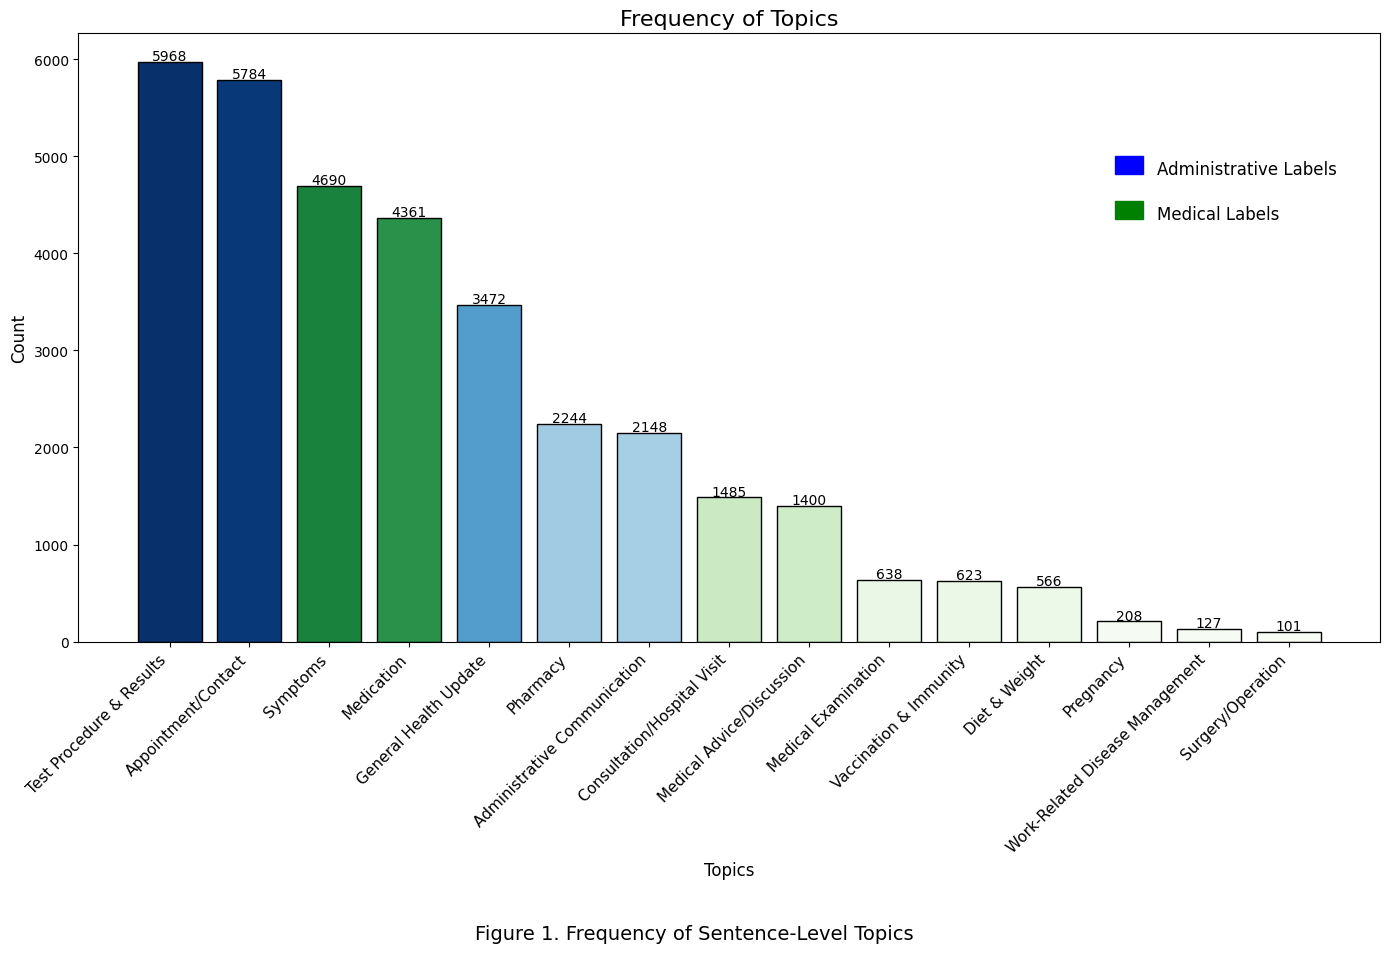

In [4]:
# plot as bar chart # This is the graph we used for ECCO abstract
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Select the relevant columns
data = labeled_topic_info[["Count", "Label_Name"]][1:]

# Sort the DataFrame by "Count" in descending order for better visualization
data = data.sort_values(by="Count", ascending=False).reset_index(drop=True)

# Normalize the counts to create a gradient effect
normalized_counts = (data["Count"] - data["Count"].min()) / (data["Count"].max() - data["Count"].min())

# Define two colormaps: Blue for administrative labels, Green for medical labels
blue_colors = plt.cm.Blues(normalized_counts)  # Administrative labels
green_colors = plt.cm.Greens(normalized_counts)  # Medical labels

# Specify which labels are administrative (blue)
administrative_labels = ["Test Procedure & Results", "Appointment/Contact", 
                         "General Health Update", "Pharmacy", "Administrative Communication"]

# Dynamically assign colors
colors = [blue_colors[i] if label in administrative_labels else green_colors[i] 
          for i, label in enumerate(data["Label_Name"])]

# Create the bar chart
plt.figure(figsize=(14, 9))
bars = plt.bar(data["Label_Name"], data["Count"], color=colors, edgecolor="black")

# Add count labels above the bars with an extended distance
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 20, int(yval), ha="center", fontsize=10)

# Add titles and labels
plt.title("Frequency of Topics", fontsize=16)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add a caption below the x-axis label
plt.figtext(0.5, -0.05, "Figure 1. Frequency of Sentence-Level Topics", 
            wrap=True, horizontalalignment="center", fontsize=14)

# Move the custom legend slightly to the left
plt.gca().add_patch(mpatches.Rectangle((0.8, 0.8), 0.02, 0.02, color="blue", transform=plt.gcf().transFigure, clip_on=False))
plt.figtext(0.83, 0.8, "Administrative Labels", fontsize=12, color="black", ha="left")

plt.gca().add_patch(mpatches.Rectangle((0.8, 0.75), 0.02, 0.02, color="green", transform=plt.gcf().transFigure, clip_on=False))
plt.figtext(0.83, 0.75, "Medical Labels", fontsize=12, color="black", ha="left")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, fontsize=11, ha="right")

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()


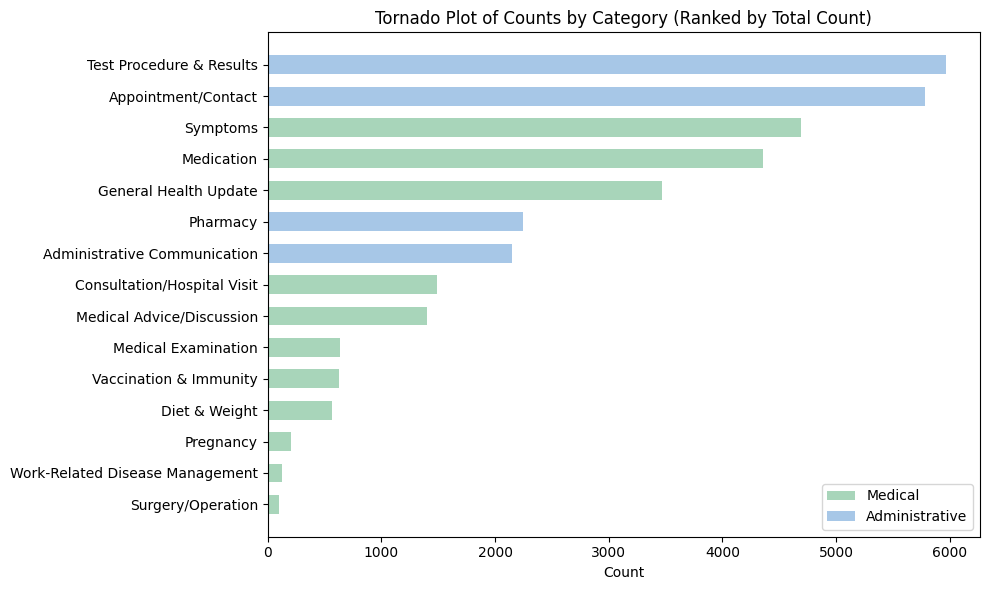

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame (replace with your actual data)

df = labeled_topic_info[["Count", "Label_Name", "Category"]][1:]

# Pivot the data so that we can have 'A' and 'M' in separate columns for each label
pivot_df = df.pivot(index='Label_Name', columns='Category', values='Count').fillna(0)

# Add a total count column, which is the sum of counts for each label across both categories
pivot_df['Total'] = pivot_df['A'] + pivot_df['M']

# Sort by the 'Total' column in descending order (highest to lowest)
pivot_df = pivot_df.sort_values(by='Total')

# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Category M on the left side of the plot (negative values for left-side bars)
ax.barh(pivot_df.index, pivot_df['M'], color='#A8D5BA', label='Medical', height=0.6)  # Softer green

# Plot Category A on the right side of the plot (positive values for right-side bars)
ax.barh(pivot_df.index, pivot_df['A'], color='#A7C7E7', label='Administrative', height=0.6)  # Softer blue

# Add labels and title
ax.set_xlabel('Count')
ax.set_title('Tornado Plot of Counts by Category (Ranked by Total Count)')
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


## 6. Compare computer labels to manual labels

### 6.1 Comparison using the small annotated set 
These are results we used for ECCO abstract

In [87]:
# check out the document info of the current model after topic merge and 
merged_doc_info = topic_model.get_document_info(sentences)
merged_doc_info.head()

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Representative_document
0,Ik ben 2 weken geleden met spoed opgenomen in ...,5,5_voel_goed_beter_gaat,"[voel, goed, beter, gaat, vorige, jaar, laatst...","[Dus dat is goed., Ik voel mij redelijk goed !...",voel - goed - beter - gaat - vorige - jaar - l...,False
1,"Ik kreeg acuut een pijnlijke druk op de borst,...",3,3_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn...",[Verder eigenlijk geen last van buikpijn gehad...,pijn - last - buikpijn - klachten - toilet - c...,False
2,Het begon 1 uur na het avondeten.,3,3_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn...",[Verder eigenlijk geen last van buikpijn gehad...,pijn - last - buikpijn - klachten - toilet - c...,False
3,"Ik had al de hele dag migraine, had dus ook we...",2,2_afspraak_contact_telefonisch_vandaag,"[afspraak, contact, telefonisch, vandaag, morg...","[9 Mei afspraak bij Dr,, afspraak is inmiddels...",afspraak - contact - telefonisch - vandaag - m...,False
4,"Ik werd heel erg misselijk, braakneigingen, du...",3,3_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn...",[Verder eigenlijk geen last van buikpijn gehad...,pijn - last - buikpijn - klachten - toilet - c...,False


In [88]:
# Save the document index as a new column "Sentence_ID" for concating with the annotated data
merged_doc_info["Sentence_ID"] = merged_doc_info.index

In [122]:
# make sure the data type is the same of the "sentence_ID" columns of the two dataframes
annotated_df_sm['Sentence_ID'] = annotated_df_sm['Sentence_ID'].astype(str)
merged_doc_info['Sentence_ID'] = merged_doc_info['Sentence_ID'].astype(str)

In [98]:
# Now perform the merge 
annotated_doc_sm = pd.merge( # merging the small annotated set with the document info
    annotated_df_sm,
    merged_doc_info[['Sentence_ID', 'Topic', 'Top_n_words']], # notice that we only choose these 3 columns of the doc info df
    on='Sentence_ID',
    how='left'
)

In [99]:
annotated_df_sm.head(5)

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label_Jiaxu
269,173,"Beste [PERSOON-1], het gaat weer iets beter ...",het gaat weer iets beter en ik heb gisteren de...,269,"Dear [PERSOON-1], things are getting better an...",A4
270,173,Het liep goed totdat ik probeerde de onderkant...,Het liep goed totdat ik probeerde de onderkant...,270,It went well until I tried to break the bottom...,A4
271,173,Ik kreeg het niet voor elkaar en heb toen meer...,Ik kreeg het niet voor elkaar en heb toen meer...,271,I couldn't do it and then I used more power.,A5
272,173,Hij lijkt me nu op de verkeerde plek gebroken ...,j lijkt me nu op de verkeerde plek gebroken (z...,272,It looks like it's broken in the wrong place (...,A5
273,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A4


In [100]:
labeled_topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs,Label,Category,Label_Name
0,0,8722,0_bedankt_dank_hoor_reactie,"[bedankt, dank, hoor, reactie, graag, hoor gra...","[Alvast bedankt voor jullie reactie., Alvast b...",A5,A,Other
1,1,5968,1_bloed_ontlasting_prikken_laten,"[bloed, ontlasting, prikken, laten, bloed late...",[ik heb ongeveer 2 weken geleden bloed laten ...,A4,A,Test Procedure & Results
2,2,5784,2_afspraak_contact_telefonisch_vandaag,"[afspraak, contact, telefonisch, vandaag, morg...","[9 Mei afspraak bij Dr,, afspraak is inmiddels...",A2,A,Appointment/Contact
3,3,4690,3_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn...",[Verder eigenlijk geen last van buikpijn gehad...,M8,M,Symptoms
4,4,4361,4_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibi...","[Ja ik gebruik 2x2 mezant per dag., Mijn medic...",M6,M,Medication


In [101]:
# now merge the above dataframe with the labeled topic info frame
annotated_doc_sm = pd.merge(
    annotated_doc_sm,
    labeled_topic_info[['Topic', 'Label', 'Category', 'Label_Name']],
    on='Topic',
    how='left'
)

In [102]:
annotated_doc_sm.head() # examine the annotated set after combining it with the computer-labels

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label_Jiaxu,Topic,Top_n_words,Label,Category,Label_Name
0,173,"Beste [PERSOON-1], het gaat weer iets beter ...",het gaat weer iets beter en ik heb gisteren de...,269,"Dear [PERSOON-1], things are getting better an...",A4,1,bloed - ontlasting - prikken - laten - bloed l...,A4,A,Test Procedure & Results
1,173,Het liep goed totdat ik probeerde de onderkant...,Het liep goed totdat ik probeerde de onderkant...,270,It went well until I tried to break the bottom...,A4,1,bloed - ontlasting - prikken - laten - bloed l...,A4,A,Test Procedure & Results
2,173,Ik kreeg het niet voor elkaar en heb toen meer...,Ik kreeg het niet voor elkaar en heb toen meer...,271,I couldn't do it and then I used more power.,A5,2,afspraak - contact - telefonisch - vandaag - m...,A2,A,Appointment/Contact
3,173,Hij lijkt me nu op de verkeerde plek gebroken ...,j lijkt me nu op de verkeerde plek gebroken (z...,272,It looks like it's broken in the wrong place (...,A5,9,advies - probleem - graag advies - zorgen - zi...,M4,M,Medical Advice/Discussion
4,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A4,1,bloed - ontlasting - prikken - laten - bloed l...,A4,A,Test Procedure & Results


In [115]:
# Also add the category of the manual label
annotated_doc_sm["Manual_Category"] = None
annotated_doc_sm.loc[annotated_doc_sm["Manual_Label_Jiaxu"].str.contains("A"), "Manual_Category"] = "A"
annotated_doc_sm.loc[annotated_doc_sm["Manual_Label_Jiaxu"].str.contains("M"), "Manual_Category"] = "M"

In [107]:
annotated_doc_sm.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label_Jiaxu,Topic,Top_n_words,Label,Category,Label_Name,Manual_Category
0,173,"Beste [PERSOON-1], het gaat weer iets beter ...",het gaat weer iets beter en ik heb gisteren de...,269,"Dear [PERSOON-1], things are getting better an...",A4,1,bloed - ontlasting - prikken - laten - bloed l...,A4,A,Test Procedure & Results,A
1,173,Het liep goed totdat ik probeerde de onderkant...,Het liep goed totdat ik probeerde de onderkant...,270,It went well until I tried to break the bottom...,A4,1,bloed - ontlasting - prikken - laten - bloed l...,A4,A,Test Procedure & Results,A
2,173,Ik kreeg het niet voor elkaar en heb toen meer...,Ik kreeg het niet voor elkaar en heb toen meer...,271,I couldn't do it and then I used more power.,A5,2,afspraak - contact - telefonisch - vandaag - m...,A2,A,Appointment/Contact,A
3,173,Hij lijkt me nu op de verkeerde plek gebroken ...,j lijkt me nu op de verkeerde plek gebroken (z...,272,It looks like it's broken in the wrong place (...,A5,9,advies - probleem - graag advies - zorgen - zi...,M4,M,Medical Advice/Discussion,M
4,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A4,1,bloed - ontlasting - prikken - laten - bloed l...,A4,A,Test Procedure & Results,A


In [119]:
# import the annotated_doc_sm if it has been saved
#annotated_doc_sm = pd.read_excel("/workspace/mijnidbcoachnlp/data/result_data/Label_comparison/label_comparison_set_small.xlsx", index_col=0)
accuracy_results_sm = {}

for label in ["A5", "A4", "A2", "M8", "M6", "M3", "A3", "A1", "M2", "M4", "M5", "M10", "M1", "M7", "M11", "M9"]:
    # Filter the annotated document by the current label
    subset = annotated_doc_sm[annotated_doc_sm["Manual_Label_Jiaxu"] == label]
    
    # Check if there is a sufficient sample size
    if len(subset) > 10:
        # Calculate the accuracy as the percentage of matches in the filtered subset
        accuracy = (subset['Manual_Label_Jiaxu'] == subset['Label']).sum() / len(subset)
        accuracy_results_sm[label] = accuracy
        # Output the accuracy
        print(f"Accuracy for Manual_Label == {label}: {accuracy * 100:.2f}%")
    else:
        print(f"Too small sample size for label {label}")


Accuracy for Manual_Label == A5: 59.32%
Accuracy for Manual_Label == A4: 66.15%
Accuracy for Manual_Label == A2: 60.00%
Accuracy for Manual_Label == M8: 33.33%
Accuracy for Manual_Label == M6: 40.00%
Too small sample size for label M3
Too small sample size for label A3
Too small sample size for label A1
Too small sample size for label M2
Accuracy for Manual_Label == M4: 25.00%
Too small sample size for label M5
Too small sample size for label M10
Too small sample size for label M1
Too small sample size for label M7
Too small sample size for label M11
Too small sample size for label M9


In [113]:
# Pring the average accuracy
accuracy_avg = (annotated_doc_sm['Manual_Label_Jiaxu'] == annotated_doc_sm['Label']).sum() / len(annotated_doc_sm)
print(f"Average Accuracy for Manual_Label: {accuracy_avg * 100:.2f}%")

Average Accuracy for Manual_Label: 50.61%


In [116]:
category_accuracy = (annotated_doc_sm['Manual_Category'] == annotated_doc_sm['Category']).sum() / len(annotated_doc_sm)
print(f"Accuracy for Category Matching: {category_accuracy * 100:.2f}%")

Accuracy for Category Matching: 73.17%


In [117]:
# save the annotated_doc_sm
annotated_doc_sm.to_excel("/workspace/mijnidbcoachnlp/data/result_data/Label_comparison/label_comparison_set_small.xlsx")

### 6.2 Comparison with big annotated set

In [127]:
annotated_df_lg['Sentence_ID'] = annotated_df_lg['Sentence_ID'].astype(str)

In [129]:
annotated_df_lg.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Manual_label_Tom
0,3,Ik ben 2 weken geleden met spoed opgenomen in ...,Ik ben 2 weken geleden met spoed opgenomen in ...,0,M8
1,3,"Ik kreeg acuut een pijnlijke druk op de borst,...","Ik kreeg acuut een pijnlijke druk op de borst,...",1,M8
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,2,A5
3,3,"Ik had al de hele dag migraine, had dus ook we...","Ik had al de hele dag migraine, had dus ook we...",3,M8
4,3,"Ik werd heel erg misselijk, braakneigingen, du...","Ik werd heel erg misselijk, braakneigingen, du...",4,M8


In [131]:
# Now perform the merge 
annotated_doc_lg = pd.merge( # merging the large annotated set with the document info
    annotated_df_lg,
    merged_doc_info[['Sentence_ID', 'Topic', 'Top_n_words']], # notice that we only choose these 3 columns of the doc info df
    on='Sentence_ID',
    how='left'
)

In [132]:
annotated_doc_lg = pd.merge(
    annotated_doc_lg,
    labeled_topic_info[['Topic', 'Label', 'Category', 'Label_Name']],
    on='Topic',
    how='left'
)

In [135]:
annotated_doc_lg.head() # examine the annotated set after combining it with the computer-labelsannotated_doc_sm

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Manual_label_Tom,Topic,Top_n_words,Label,Category,Label_Name
0,3,Ik ben 2 weken geleden met spoed opgenomen in ...,Ik ben 2 weken geleden met spoed opgenomen in ...,0,M8,5,voel - goed - beter - gaat - vorige - jaar - l...,M3,M,General Health Update
1,3,"Ik kreeg acuut een pijnlijke druk op de borst,...","Ik kreeg acuut een pijnlijke druk op de borst,...",1,M8,3,pijn - last - buikpijn - klachten - toilet - c...,M8,M,Symptoms
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,2,A5,3,pijn - last - buikpijn - klachten - toilet - c...,M8,M,Symptoms
3,3,"Ik had al de hele dag migraine, had dus ook we...","Ik had al de hele dag migraine, had dus ook we...",3,M8,2,afspraak - contact - telefonisch - vandaag - m...,A2,A,Appointment/Contact
4,3,"Ik werd heel erg misselijk, braakneigingen, du...","Ik werd heel erg misselijk, braakneigingen, du...",4,M8,3,pijn - last - buikpijn - klachten - toilet - c...,M8,M,Symptoms


In [136]:
# Also add the category of the manual label
annotated_doc_lg["Manual_Category"] = None
annotated_doc_lg.loc[annotated_doc_lg["Manual_label_Tom"].str.contains("A"), "Manual_Category"] = "A"
annotated_doc_lg.loc[annotated_doc_lg["Manual_label_Tom"].str.contains("M"), "Manual_Category"] = "M"

In [139]:
# import the annotated_doc_sm if it has been saved
#annotated_doc_sm = pd.read_excel("/workspace/mijnidbcoachnlp/data/result_data/Label_comparison/label_comparison_set_small.xlsx", index_col=0)
accuracy_results_lg = {}

for label in ["A5", "A4", "A2", "M8", "M6", "M3", "A3", "A1", "M2", "M4", "M5", "M10", "M1", "M7", "M11", "M9"]:
    # Filter the annotated document by the current label
    subset = annotated_doc_lg[annotated_doc_lg["Manual_label_Tom"] == label]
    
    # Check if there is a sufficient sample size
    if len(subset) > 10:
        # Calculate the accuracy as the percentage of matches in the filtered subset
        accuracy = (subset['Manual_label_Tom'] == subset['Label']).sum() / len(subset)
        accuracy_results_lg[label] = accuracy
        # Output the accuracy
        print(f"Accuracy for Manual_Label == {label}: {accuracy * 100:.2f}%")
    else:
        print(f"Too small sample size for label {label}")


Accuracy for Manual_Label == A5: 63.35%
Accuracy for Manual_Label == A4: 56.82%
Accuracy for Manual_Label == A2: 54.79%
Accuracy for Manual_Label == M8: 44.75%
Accuracy for Manual_Label == M6: 38.81%
Accuracy for Manual_Label == M3: 26.71%
Accuracy for Manual_Label == A3: 53.93%
Accuracy for Manual_Label == A1: 12.20%
Accuracy for Manual_Label == M2: 28.00%
Accuracy for Manual_Label == M4: 14.44%
Accuracy for Manual_Label == M5: 8.74%
Accuracy for Manual_Label == M10: 25.42%
Accuracy for Manual_Label == M1: 33.33%
Accuracy for Manual_Label == M7: 39.73%
Too small sample size for label M11
Accuracy for Manual_Label == M9: 15.00%


In [140]:
# Pring the average accuracy
accuracy_avg_lg = (annotated_doc_lg['Manual_label_Tom'] == annotated_doc_lg['Label']).sum() / len(annotated_doc_lg)
print(f"Average Accuracy for Manual_Label: {accuracy_avg_lg * 100:.2f}%")

Average Accuracy for Manual_Label: 42.58%


In [142]:
category_accuracy_lg = (annotated_doc_lg['Manual_Category'] == annotated_doc_lg['Category']).sum() / len(annotated_doc_lg)
print(f"Accuracy for Category Matching: {category_accuracy_lg * 100:.2f}%")

Accuracy for Category Matching: 71.96%
